## **🫱고령 남성의 손 구조 유형 분류 – 손가락 마디 및 손둘레 기반 군집 분석**

### **📜분석절차**
1. **데이터전처리 - 고령 남성 추출, 변수선택, 결측치처리**
2. **T-test(2030 vs 70↑) : 연령이 손 구조에 영향을 주는가?**
4. **정규화 - 변수 표준화 z-score (평균0 표준편차1)**
5. **요인분석 - 비슷한 변수끼리 묶음**  
6. **군집분석 - 손 구조 유형 분류**
7. **군집해석**
8. **결론**

🔎**분석항목**

- 너비
    - 검지손가락끝마디너비 / 가운데손가락끝마디너비 / 반지손가락끝마디너비 / 새끼손가락끝마디너비 /
검지손가락중간마디너비 / 가운데손가락중간마디너비 / 반지손가락중간마디너비 / 새끼손가락중간마디너비

- 둘레
    - 검지손가락끝마디둘레 / 가운데손가락끝마디둘레 / 반지손가락끝마디둘레 / 새끼손가락끝마디둘레 /
검지손가락중간마디둘레 / 가운데손가락중간마디둘레 / 반지손가락중간마디둘레 / 새끼손가락중간마디둘레 / 손둘레

- 길이
    - 손직선길이 / 검지손가락직선길이 / 가운데손가락직선길이 / 반지손가락직선길이 / 새끼손가락직선길이 /
손바닥직선길이 / 손안쪽가쪽직선길이

- 두께
    - 손두께 / 손두께(2/3 지점)


### **1. 데이터전처리 - 고령 남성 추출, 변수선택, 결측치처리**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#70세 이상 손 치수데이터
df = pd.read_csv('C:/Users/FORYOUCOM/Desktop/인체치수조사_치수데이터(공개용)/고령손_8차 인체치수조사(2020~23).csv', 
                 encoding='utf-8')

#남성만 필터링
df= df.loc[df['성별']=='남', :]

#결측치 확인결과 -> 결측치 없음
# df.isnull().sum()

#앞에 붙은 숫자 제거  (336. 손직선길이 → 손직선길이)
old_cols = df.columns[3:]
new_cols = []
for col in old_cols:
    temp = col.split('.')[1].strip()
    new_cols.append(temp)
df.rename(columns=dict(zip(old_cols, new_cols)), inplace=True)

#분석항목 필터링
df.drop([
    # 첫마디 관련 길이 - 중간/끝마디와 유사 패턴, 정보 중복
    '손목중심-엄지손가락첫마디길이',
    '손목중심-검지손가락첫마디길이',
    '손목중심-반지손가락첫마디길이',
    '손목중심-새끼손가락첫마디길이',

    # 복합구간 길이 - 측정 지점이 복잡하고 해석 어려움
    '손목가쪽-엄지손가락손끝길이',
    '엄지손가락첫마디-검지손가락첫마디직선길이',

    # 첫마디 둘레 - 중복 정보 많고 영향 낮음으로 판단
    '엄지손가락첫마디둘레',
    '검지손가락첫마디둘레',
    '가운데손가락첫마디둘레',
    '반지손가락첫마디둘레',
    '새끼손가락첫마디둘레'
], axis=1, inplace=True)

In [3]:
df.shape

(211, 31)

In [4]:
df.describe()

,나이,손직선길이,엄지손가락직선길이,검지손가락직선길이,가운데손가락직선길이,반지손가락직선길이,새끼손가락직선길이,손바닥직선길이,검지손가락끝마디너비,가운데손가락끝마디너비,...,가운데손가락끝마디둘레,반지손가락끝마디둘레,새끼손가락끝마디둘레,검지손가락중간마디둘레,가운데손가락중간마디둘레,반지손가락중간마디둘레,새끼손가락중간마디둘레,손둘레,손두께,손두께(2/3 지점)
count,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,...,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000
mean,75.867299,181.435071,52.624645,70.437915,78.070616,74.616588,58.906635,103.425118,18.462085,18.581517,...,58.667773,55.452133,51.584360,67.752607,69.555450,66.786256,59.107583,215.490995,31.856872,44.056872
std,3.844777,7.824388,3.962450,4.655359,5.051071,4.702336,4.999500,5.400034,1.154817,1.205973,...,3.083088,3.101925,4.306594,3.411218,3.692374,3.457187,3.960476,8.957581,2.418360,2.795113
min,70.000000,159.800000,41.100000,57.200000,61.100000,61.100000,41.100000,86.200000,15.100000,15.100000,...,51.700000,45.700000,41.400000,60.000000,59.300000,58.600000,50.000000,194.000000,26.200000,38.000000
25%,73.000000,176.650000,50.250000,67.400000,74.850000,71.200000,55.650000,100.000000,17.700000,17.800000,...,56.500000,53.400000,49.200000,65.100000,67.000000,64.200000,56.350000,209.750000,30.100000,42.100000
50%,75.000000,181.400000,53.000000,70.700000,78.900000,74.800000,59.200000,103.300000,18.500000,18.600000,...,58.400000,55.400000,51.500000,67.800000,69.400000,66.700000,59.100000,215.800000,32.000000,43.900000
75%,79.000000,186.950000,55.450000,73.700000,81.350000,77.800000,62.800000,107.000000,19.250000,19.300000,...,60.500000,57.300000,53.900000,70.150000,72.100000,68.900000,61.350000,221.600000,33.500000,45.700000
max,84.000000,203.800000,62.600000,83.300000,90.600000,87.100000,70.100000,116.500000,21.700000,22.000000,...,67.900000,64.200000,69.200000,79.500000,80.900000,76.600000,71.800000,243.300000,38.400000,53.100000


### **2. T-test(2030 vs 70↑) : 연령이 손 구조에 영향을 주는가?**

In [11]:
#20~69세 전체 치수데이터
young_df = pd.read_csv('C:/Users/FORYOUCOM/Desktop/인체치수조사_치수데이터(공개용)/3D_8차 인체치수조사(2020~23).csv', 
                 encoding='utf-8', header=6)

#기본정보와 손 컬럼만 필터링
young_df = young_df.iloc[:, np.r_[1:4, 287:326]]

#남성만 필터링
young_df= young_df.loc[young_df['성별']=='M',:]

#결측치제거
young_df=young_df.dropna()

# #2030 연령대만 필터링
young_df = young_df[(young_df['나이']>=20) & (young_df['나이']<40)]

#앞에 붙은 숫자 제거  (336. 손직선길이 → 손직선길이)
old_cols = young_df.columns[3:]
new_cols = []
for col in old_cols:
    temp = col.split('.')[1].strip()
    new_cols.append(temp)

young_df.rename(columns=dict(zip(old_cols, new_cols)), inplace=True)

#분석항목 필터링
young_df.drop([
    # 첫마디 관련 길이 - 중간/끝마디와 유사 패턴, 정보 중복
    '손목중심-엄지손가락첫마디길이',
    '손목중심-검지손가락첫마디길이',
    '손목중심-반지손가락첫마디길이',
    '손목중심-새끼손가락첫마디길이',

    # 복합구간 길이 - 측정 지점이 복잡하고 해석 어려움
    '손목가쪽-엄지손가락손끝길이',
    '엄지손가락첫마디-검지손가락첫마디직선길이',

    # 첫마디 둘레 - 중복 정보 많고 영향 낮음으로 판단
    '엄지손가락첫마디둘레',
    '검지손가락첫마디둘레',
    '가운데손가락첫마디둘레',
    '반지손가락첫마디둘레',
    '새끼손가락첫마디둘레'
], axis=1, inplace=True)

In [10]:
young_df.shape

(1342, 31)

In [16]:
import scipy.stats as stats

hand_cols = df.columns[3:]

#t-test (젊은남성 손 컬럼 vs 고령남성 손 컬럼)
for col in hand_cols:
    g1 = df.loc[:, col]
    g2 = young_df.loc[:, col]
    t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=True)

    print(col)
    print(f"    F값 : {t_stat:.2f}")
    print(f"    p값 : {p_value:.2f}")

손직선길이
    F값 : -3.50
    p값 : 0.00
엄지손가락직선길이
    F값 : 4.42
    p값 : 0.00
검지손가락직선길이
    F값 : -0.95
    p값 : 0.34
가운데손가락직선길이
    F값 : -2.50
    p값 : 0.01
반지손가락직선길이
    F값 : 5.76
    p값 : 0.00
새끼손가락직선길이
    F값 : 9.52
    p값 : 0.00
손바닥직선길이
    F값 : -2.46
    p값 : 0.01
검지손가락끝마디너비
    F값 : 29.31
    p값 : 0.00
가운데손가락끝마디너비
    F값 : 25.51
    p값 : 0.00
반지손가락끝마디너비
    F값 : 22.54
    p값 : 0.00
새끼손가락끝마디너비
    F값 : 33.83
    p값 : 0.00
검지손가락중간마디너비
    F값 : 18.43
    p값 : 0.00
가운데손가락중간마디너비
    F값 : 18.81
    p값 : 0.00
반지손가락중간마디너비
    F값 : 19.04
    p값 : 0.00
새끼손가락중간마디너비
    F값 : 22.67
    p값 : 0.00
손안쪽가쪽직선길이
    F값 : 10.03
    p값 : 0.00
엄지손가락끝마디둘레
    F값 : 19.95
    p값 : 0.00
검지손가락끝마디둘레
    F값 : 31.83
    p값 : 0.00
가운데손가락끝마디둘레
    F값 : 29.92
    p값 : 0.00
반지손가락끝마디둘레
    F값 : 28.42
    p값 : 0.00
새끼손가락끝마디둘레
    F값 : 43.96
    p값 : 0.00
검지손가락중간마디둘레
    F값 : 26.12
    p값 : 0.00
가운데손가락중간마디둘레
    F값 : 24.94
    p값 : 0.00
반지손가락중간마디둘레
    F값 : 27.66
    p값 : 0.00
새끼손가락중간마디둘레
    F값 : 38.66
    p값 : 0.00
손둘레


### **3. 정규화 - 변수 표준화(평균0 표준편차1)**
손둘레(180) vs 손가락너비(15) 같이 단위 차이 매우 큼
각 변수의 단위와 크기가 다르므로 표준화 (z-score) 수행 → 평균 0, 표준편차 1로 맞춰줌

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.iloc[:,3:]), columns=df.columns[3:])
df_scaled

,손직선길이,엄지손가락직선길이,검지손가락직선길이,가운데손가락직선길이,반지손가락직선길이,새끼손가락직선길이,손바닥직선길이,검지손가락끝마디너비,가운데손가락끝마디너비,반지손가락끝마디너비,...,가운데손가락끝마디둘레,반지손가락끝마디둘레,새끼손가락끝마디둘레,검지손가락중간마디둘레,가운데손가락중간마디둘레,반지손가락중간마디둘레,새끼손가락중간마디둘레,손둘레,손두께,손두께(2/3 지점)
0,1.917149,0.676783,1.089953,1.732334,1.488626,0.259314,1.146209,-1.355885,-0.400226,0.418343,...,-0.412180,0.597133,-0.601521,-0.750077,-0.286526,-0.198973,-0.280324,0.605283,-1.059790,-0.163843
1,0.149238,-0.815736,-1.106281,-0.986412,0.294896,-0.322123,1.127646,-0.835087,-0.898933,-1.050110,...,-1.290008,-1.309435,-0.694623,-1.602235,-1.643888,-0.604890,0.251176,-0.457794,-0.603854,-1.203835
2,0.636054,2.219895,-0.826368,-0.252152,0.230947,0.299413,1.146209,-1.442685,-1.646993,-0.968529,...,-1.842714,-1.729527,-1.788568,-1.132079,-1.481005,-1.706663,-1.900134,-0.368271,-2.220352,-0.737632
3,2.865159,1.688660,2.188070,2.486439,2.661039,1.803131,1.814457,1.595305,0.347834,0.907827,...,0.335599,0.338615,-0.112737,0.924854,1.070837,0.525878,-0.330943,0.952181,-1.764417,-0.056257
4,0.405457,0.196141,0.099495,0.025676,-0.003536,-0.101578,0.570773,-1.095486,-0.233990,-1.131690,...,-0.477204,-1.050917,-1.579089,-0.897001,-0.693735,-0.981812,-1.191467,-0.636838,-0.686752,-1.132112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,-0.158224,1.283909,-1.278534,-0.529980,-0.344602,-1.304552,0.255212,0.466908,0.763423,-3.987014,...,-0.119571,-1.826471,0.585526,-0.838231,-0.286526,-1.213765,-0.027229,-0.413033,0.308017,-1.060388
207,-0.580985,0.626189,-0.611051,-0.668894,-1.303849,-2.407278,-0.227412,-1.008687,-0.566462,-0.968529,...,-0.867350,-0.533882,-2.323902,-1.249618,-0.693735,-0.981812,-1.368634,-2.002052,-1.598622,-0.916941
208,-0.606607,0.575595,-0.675647,-0.609360,-1.175949,-2.347130,-0.338787,-1.095486,-0.483344,-0.886948,...,-0.834838,-0.501567,-2.370453,-1.279003,-0.666587,-0.981812,-1.545801,-1.968481,-1.681520,-0.881079
209,0.046751,-0.259204,-0.331139,0.243970,-0.685667,-1.224354,-0.171725,0.119710,0.015363,0.173601,...,0.140526,0.241671,0.259670,-0.044843,0.663628,0.380907,-0.584039,-0.547316,-0.728200,0.338223


### **4. 요인분석 - 비슷한 변수끼리 묶음**

### 요인수 결정) 고유값 ≥ 1 기준 (Kaiser 기준)

In [31]:
from factor_analyzer import FactorAnalyzer
import numpy as np

np.set_printoptions(suppress=True, precision=2)

fa = FactorAnalyzer()
fa.fit(df.iloc[:, 3:])

eigen_values, _ = fa.get_eigenvalues()
print(eigen_values)

[13.06  3.49  1.82  1.51  1.04  0.92  0.9   0.68  0.65  0.55  0.48  0.42
  0.39  0.33  0.31  0.24  0.21  0.2   0.18  0.13  0.11  0.08  0.08  0.07
  0.05  0.05  0.04  0.  ]


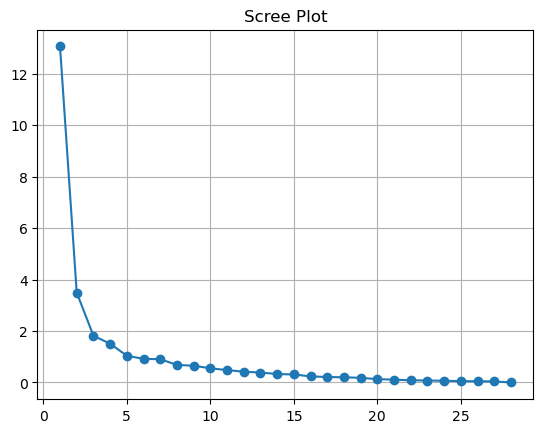

In [28]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(eigen_values) + 1), eigen_values, marker='o')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

-> 1보다 높은 고유값 : 5개

In [33]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(df.iloc[:,3:])

loadings = pd.DataFrame(fa.loadings_, index=df.columns[3:], columns=["요인1", "요인2","요인3","요인4", "요인5"])
loadings.round(2)

,요인1,요인2,요인3,요인4,요인5
손직선길이,0.27,0.66,0.03,0.10,0.69
엄지손가락직선길이,0.05,0.56,0.05,0.03,0.12
검지손가락직선길이,0.09,0.83,0.00,0.19,-0.04
가운데손가락직선길이,0.29,0.88,-0.01,0.00,0.06
반지손가락직선길이,0.14,0.87,0.13,0.03,0.06
새끼손가락직선길이,-0.04,0.72,0.23,-0.03,-0.03
손바닥직선길이,0.14,0.11,0.07,0.14,0.82
검지손가락끝마디너비,0.47,-0.01,0.26,0.64,0.17
가운데손가락끝마디너비,0.71,0.06,0.28,0.21,0.15
반지손가락끝마디너비,0.58,0.08,0.38,0.27,0.18


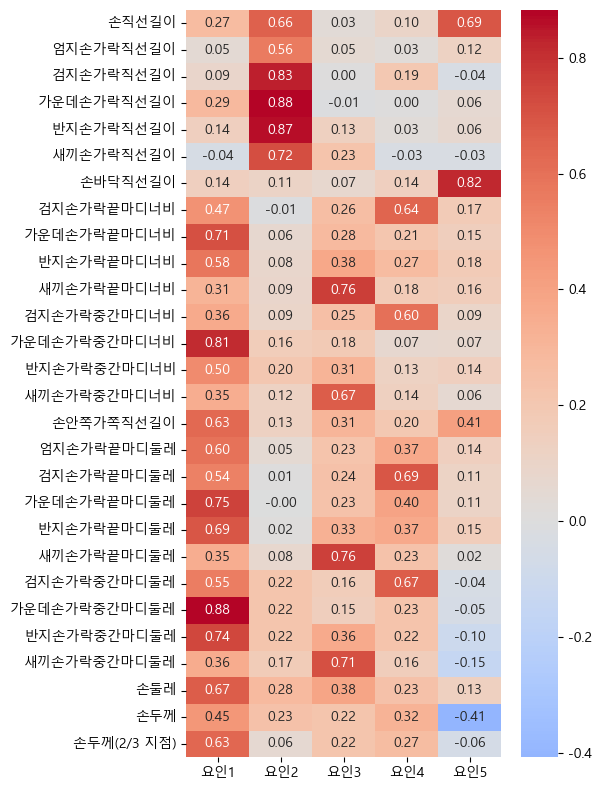

In [49]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스(-) 깨짐 방지

# 히트맵 시각화
plt.figure(figsize=(6, 8))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, cbar=True, fmt=".2f")
plt.tight_layout()
plt.show()

📊 히트맵 해석 요령
빨간색에 가까울수록 해당 요인과 변수의 관련성(부하량)이 높음
부하량이 0.4 이상이면 해당 요인에 의미 있게 묶인 변수라고 볼 수 있음
열 별로 관련 변수들이 비슷한 특성을 나타냄

🧠 각 요인 해석 예시
✅ 요인1 (굵기, 둘레 중심 요인)
→ 손가락과 손의 굵기/둘레 중심 특성을 대표하는 요인

✅ 요인2 (길이 중심 요인)
→ 손가락의 길이적 특성을 반영하는 요인

✅ 요인3 (중간마디 중심 요인)
→ 손의 내부 길이 및 중간 부위 형태를 나타내는 요인

✅ 요인4 (손바닥/기초구조 요인)
관련 변수:손바닥직선길이, 엄지손가락쪽 직선길이, 손안쪽가쪽직선길이, 중간마디, 손두께
→ 손의 기초 구조 또는 기저 형태 관련

✅ 요인5 (반대 성격 혹은 잔여 요인)
손두께, 중간마디, 둘레 중 일부에서 부정적 로딩(파란색)
→ 다른 요인에 설명되지 않은 잔여적 특성 또는 음의 상관관계

🧩 결론적으로
요인 1, 2는 가장 강한 패턴 (굵기 / 길이)
요인 3, 4는 구조적 특성
요인 5는 잔차적 요인으로 의미가 다소 약할 수 있음

### **5. 군집분석 - 손 구조 유형 분류**

In [52]:
from factor_analyzer import FactorAnalyzer
import pandas as pd

# 요인분석 (요인 수는 적절하게 조정)
fa = FactorAnalyzer
(n_factors=5, rotation='varimax')
fa.fit(df.iloc[:, 3:])

# 요인 점수 계산
factor_scores = fa.transform(df.iloc[:, 3:])
factor_df = pd.DataFrame(factor_scores, columns=["요인1", "요인2", "요인3", "요인4", "요인5"])
factor_df

,요인1,요인2,요인3,요인4,요인5
0,-0.684654,3.150568,-0.934343,-1.203869,9.792054
1,-1.589844,0.426842,0.092172,-0.945027,4.778146
2,-0.980061,-0.271994,-0.651099,-1.138941,-1.628984
3,0.311034,2.487486,-0.508624,0.734407,2.869878
4,-0.003128,-0.954572,-0.717719,-0.549640,-5.614531
...,...,...,...,...,...
206,-0.842668,-0.618579,0.471490,0.044357,-0.096466
207,-0.144889,-0.837810,-2.394283,-0.632853,0.162113
208,-0.632103,0.736784,-3.375722,-0.747457,8.534080
209,0.105894,1.138386,-1.347154,-0.526486,8.264493


In [58]:
from sklearn.cluster import KMeans

# 클러스터 수 설정 (예: 3개)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(factor_df)

# 클러스터 결과 추가
factor_df["cluster"] = clusters

# 각 클러스터별 평균 확인
cluster_means = factor_df.groupby("cluster").mean()
print(cluster_means)

              요인1       요인2       요인3       요인4        요인5
cluster                                                   
0        0.132751 -0.349010  0.105837 -0.075792  -1.704105
1        1.121089 -3.180416  1.870131 -0.047899 -17.288068
2       -0.498110  1.377757 -0.682878  0.111070   7.242008


C:\Users\FORYOUCOM\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


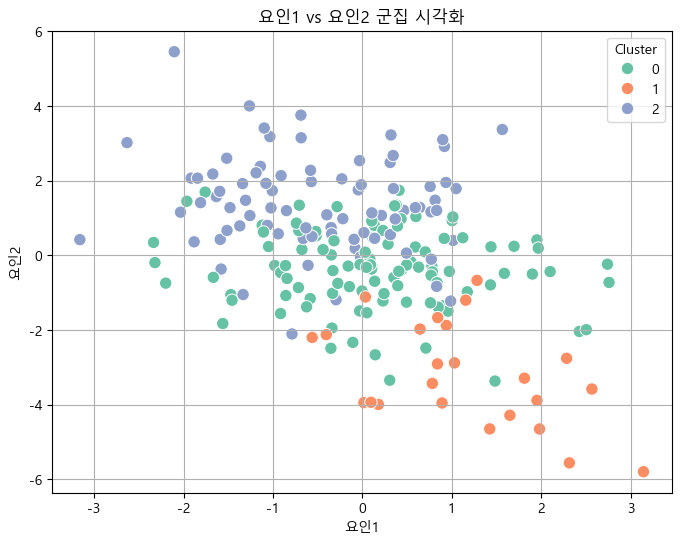

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=factor_df["요인1"], 
    y=factor_df["요인2"], 
    hue=factor_df["cluster"], 
    palette="Set2", 
    s=80
)
plt.title("요인1 vs 요인2 군집 시각화")
plt.xlabel("요인1")
plt.ylabel("요인2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [60]:
factor_df["cluster"].value_counts()

cluster
0    105
2     82
1     24
Name: count, dtype: int64

🧩 Cluster 0
요인1: + (중간보다 약간 굵은 손가락 및 손 구조)
요인2: - (손가락 길이가 짧음)
요인5: 매우 - 🔻

📝 해석:
전체적으로 손가락은 굵지만 짧은 형태
요인5가 크게 음수인 것으로 보아, 특이한 구조(예: 압축된 구조 또는 손의 비대칭적 특성 등)도 포함되어 있을 수 있음
현실적으로 보면 손가락이 짧고 굵은 구조의 손 형태

🧩 Cluster 1
요인1, 3: 매우 +
요인2: 매우 -
요인5: 극단적 음수(-17!) ⚠️

📝 해석:
손가락은 매우 굵고 마디도 크다 (요인1, 3 높음)
반면 길이는 매우 짧다 (요인2 매우 낮음)
요인5가 극단적으로 낮은 값을 보여서, 이 군집은 데이터 분포 상 특이치일 가능성 있음 (극소수만 해당될 수도 있어)

→ ✔️ 비정상적으로 굵고 짧은 손 유형
→ 또는 손의 형태가 전반적으로 왜곡된 형태

🧩 Cluster 2
요인1, 3: - (얇은 손가락, 마디 작음)
요인2: + (길이가 김)
요인5: +7 🔼

📝 해석:
손가락이 길고 얇은 형태
요인5가 높으므로, 손가락 간 비율이 정돈되어 있고 전체적으로 균형 잡힌 긴 손일 가능성

→ ✔️ 얇고 긴 손 구조

📌 정리하면…
군집	손가락 길이	굵기/둘레	요약 설명
Cluster 0	짧음 🔽	보통 ~ 약간 굵음 ⬆	짧고 다소 굵은 손
Cluster 1	매우 짧음 🔽🔽	매우 굵음 ⬆⬆	극단적으로 짧고 굵은 손 (특이형)
Cluster 2	김 ⬆	얇음 🔽	길고 가느다란 손

### **6. 군집해석**

### **7. 결론**